<a href="https://colab.research.google.com/github/T12-alt/Tanushree_Vijaykar/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv('/content/sales_dataset.csv')

/tmp/ipykernel_4815/1793146830.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/sales_dataset.csv')


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [70]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [71]:
df.drop('Unnamed: 22', axis=1, inplace=True)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [73]:
median_amount = df['Amount'].median()

df['Amount'] = df['Amount'].fillna(median_amount)

In [74]:
df['currency'] = df['currency'].fillna(df['currency'].mode()[0])

In [75]:
df['Courier Status'] = df['Courier Status'].fillna('Unknown')

In [76]:
df['promotion-ids'] = df['promotion-ids'].fillna('No Promotion')

In [77]:
df['fulfilled-by'] = df['fulfilled-by'].fillna('Not Specified')

In [78]:
df['ship-service-level'] = df['ship-service-level'].fillna(df['ship-service-level'].mode()[0])

df['Style'] = df['Style'].fillna(df['Style'].mode()[0])

df['SKU'] = df['SKU'].fillna(df['SKU'].mode()[0])

df['Category'] = df['Category'].fillna(df['Category'].mode()[0])

df['Size'] = df['Size'].fillna(df['Size'].mode()[0])

df['ASIN'] = df['ASIN'].fillna(df['ASIN'].mode()[0])

df['Qty'] = df['Qty'].fillna(df['Qty'].median())

df['B2B'] = df['B2B'].fillna(False)

In [79]:
df['ship-city'] = df['ship-city'].fillna('Unknown')

df['ship-state'] = df['ship-state'].fillna('Unknown')

df['ship-country'] = df['ship-country'].fillna('Unknown')

df['ship-postal-code'] = df['ship-postal-code'].fillna(df['ship-postal-code'].median())

In [80]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


In [81]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_4815/2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [82]:
df['Month'] = df['Date'].dt.month_name()

df['Year'] = df['Date'].dt.year

df['Day'] = df['Date'].dt.day

In [83]:
df['Status'].value_counts()

,count
Status,
Shipped,77767
Shipped - Delivered to Buyer,28771
Cancelled,18341
Shipped - Returned to Seller,1953
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


**Assignment Task 1:** Financial Performance Analysis

In [84]:
total_revenue = df['Amount'].sum()

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 83290542.94


In [85]:
aov = df['Amount'].mean()

print("Average Order Value:", round(aov,2))

Average Order Value: 645.92


In [86]:
df['Date'] = pd.to_datetime(df['Date'])

In [87]:
df['Month'] = df['Date'].dt.to_period('M')

In [88]:
monthly_revenue = df.groupby('Month')['Amount'].sum()

monthly_revenue

,Amount
Month,
2022-03,107128.85
2022-04,30647735.96
2022-05,27737127.75
2022-06,24798550.38


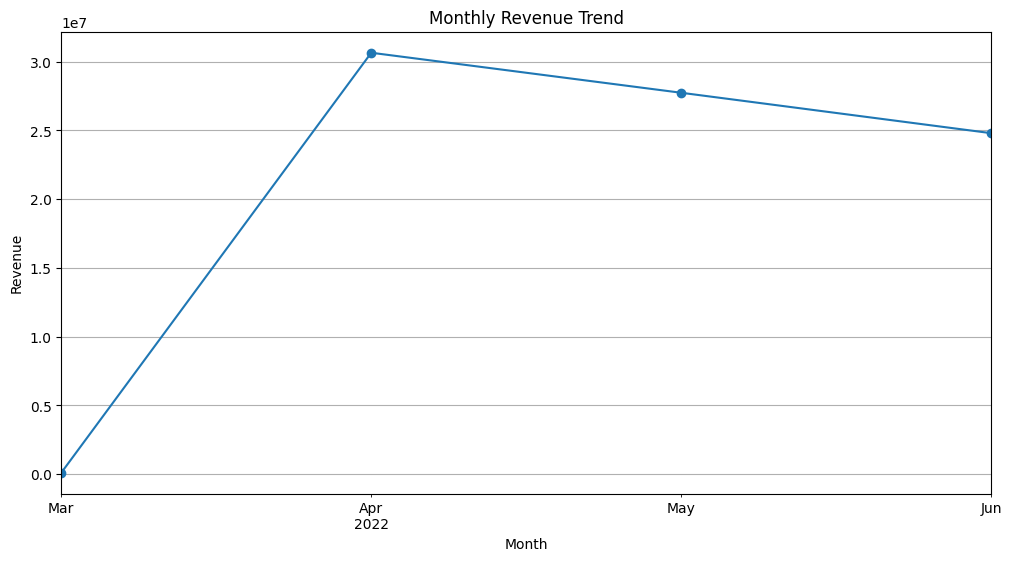

In [89]:
plt.figure(figsize=(12,6))

monthly_revenue.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

In [90]:
category_sales = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)

category_sales.head(10)

,Qty
Category,
Set,45288
kurta,45049
Western Dress,13943
Top,9902
Ethnic Dress,1052
Blouse,864
Bottom,398
Saree,152
Dupatta,3


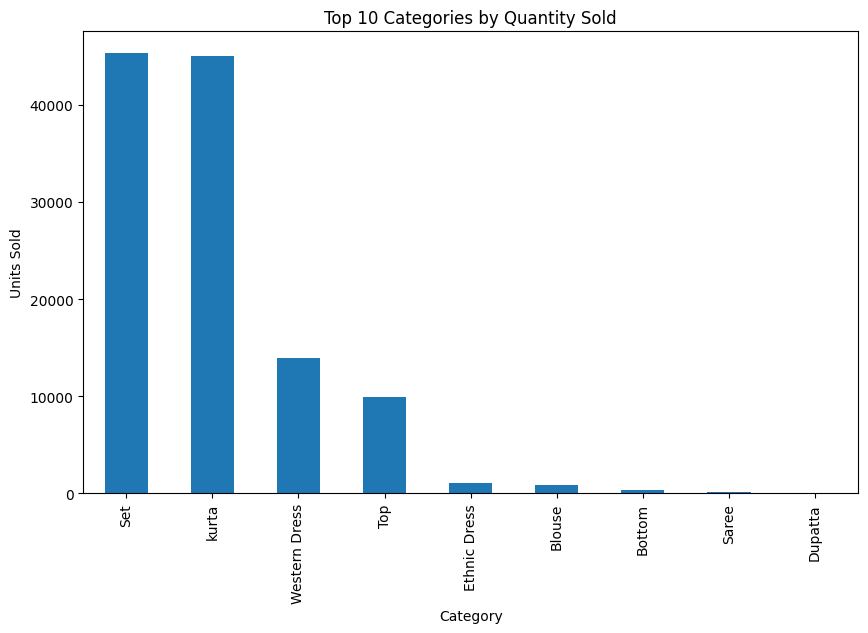

In [91]:
plt.figure(figsize=(10,6))

category_sales.head(10).plot(kind='bar')

plt.title('Top 10 Categories by Quantity Sold')
plt.ylabel('Units Sold')

plt.show()

In [92]:
revenue_by_category = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

revenue_by_category.head(10)

,Amount
Category,
Set,41157496.67
kurta,23206327.70
Western Dress,11694003.69
Top,5623727.30
Ethnic Dress,830292.66
Blouse,485633.18
Bottom,162767.98
Saree,129378.76
Dupatta,915.00


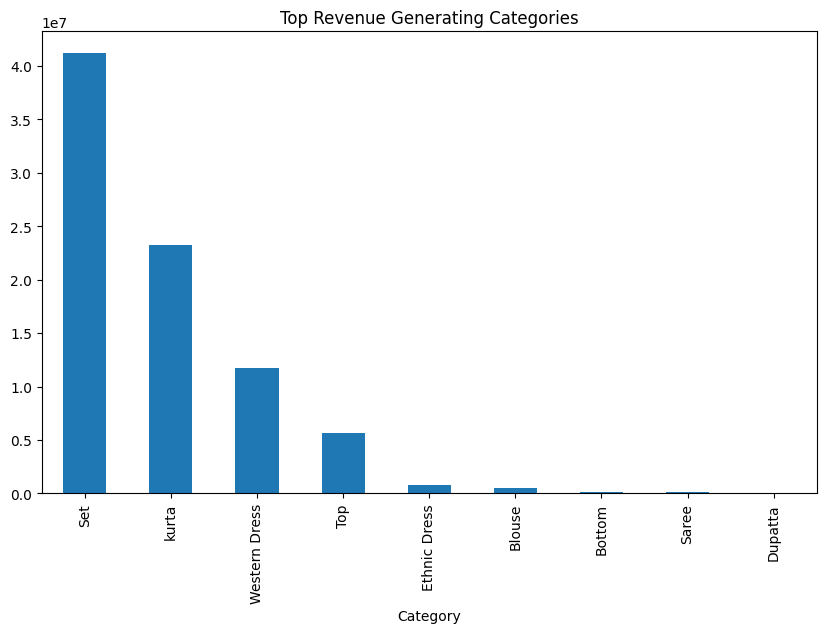

In [93]:
plt.figure(figsize=(10,6))

revenue_by_category.head(10).plot(kind='bar')

plt.title('Top Revenue Generating Categories')

plt.show()

In [94]:
size_sales = df.groupby('Size')['Qty'].sum().sort_values(ascending=False)

size_sales

,Qty
Size,
M,20450
L,19993
XL,18929
XXL,16511
S,15337
3XL,13526
XS,9939
6XL,688
5XL,513


In [95]:
top_sku = df.groupby('SKU')['Qty'].sum().sort_values(ascending=False)

top_sku.head(10)

,Qty
SKU,
JNE3797-KR-L,661
JNE3797-KR-M,561
JNE3797-KR-S,503
JNE3405-KR-L,485
J0230-SKD-M,469
J0230-SKD-S,421
JNE3797-KR-XL,416
JNE3405-KR-S,399
JNE3797-KR-XS,386


In [96]:
category_percent = (
    revenue_by_category / revenue_by_category.sum()
) * 100

category_percent.round(2)

,Amount
Category,
Set,49.41
kurta,27.86
Western Dress,14.04
Top,6.75
Ethnic Dress,1.00
Blouse,0.58
Bottom,0.20
Saree,0.16
Dupatta,0.00


**Assignment Task 2:** Customer Insights Analysis

In [97]:
top_states = (
    df.groupby('ship-state')['Amount']
    .sum()
    .sort_values(ascending=False)
)

top_states.head(10)

,Amount
ship-state,
MAHARASHTRA,14051391.14
KARNATAKA,11041795.37
TELANGANA,7333985.65
UTTAR PRADESH,7232467.08
TAMIL NADU,6921696.11
DELHI,4469778.97
KERALA,4092797.58
WEST BENGAL,3758705.44
ANDHRA PRADESH,3446162.72


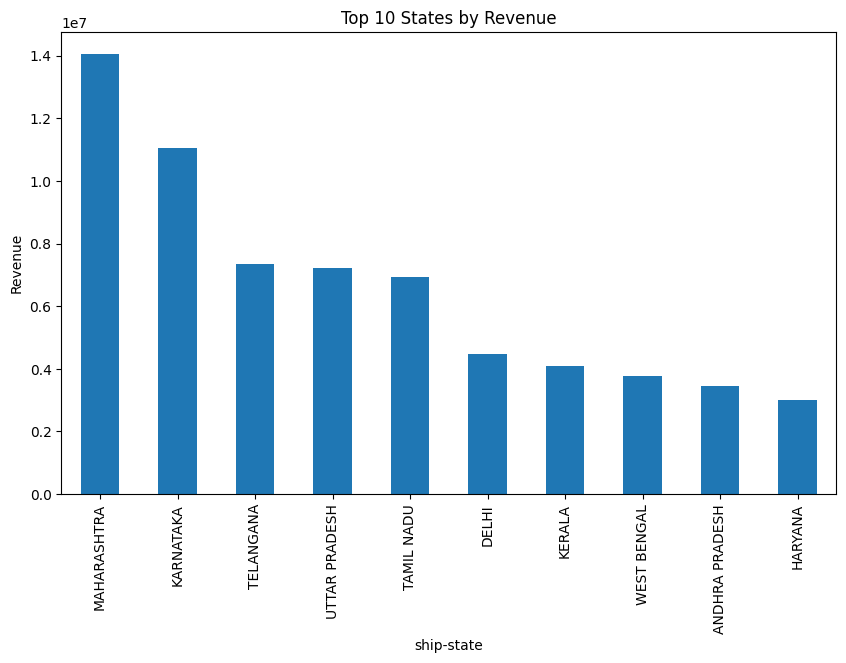

In [98]:
plt.figure(figsize=(10,6))

top_states.head(10).plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.ylabel('Revenue')
plt.show()

In [99]:
top_cities = (
    df.groupby('ship-city')['Amount']
    .sum()
    .sort_values(ascending=False)
)

top_cities.head(10)

,Amount
ship-city,
BENGALURU,7168345.99
HYDERABAD,5227277.82
MUMBAI,3859728.80
NEW DELHI,3821817.78
CHENNAI,3273076.74
PUNE,2458668.18
KOLKATA,1497258.87
GURUGRAM,1272493.74
THANE,1061225.29


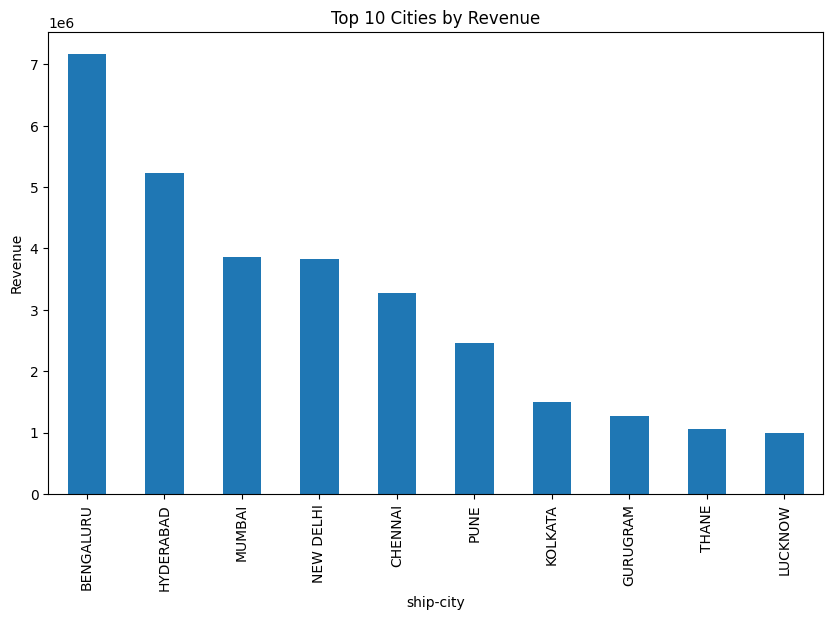

In [100]:
plt.figure(figsize=(10,6))

top_cities.head(10).plot(kind='bar')

plt.title('Top 10 Cities by Revenue')
plt.ylabel('Revenue')
plt.show()

In [101]:
df['B2B'].value_counts()

,count
B2B,
False,128078
True,871


In [102]:
df.groupby('B2B')['Amount'].agg(['count','sum','mean'])

,count,sum,mean
B2B,,,
False,128078,82682382.15,645.562721
True,871,608160.79,698.232824


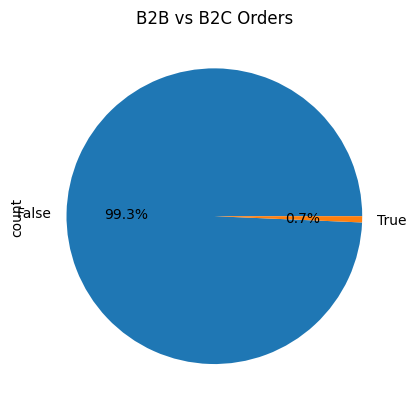

In [103]:
b2b_orders = df['B2B'].value_counts()

b2b_orders.plot(kind='pie', autopct='%1.1f%%')
plt.title('B2B vs B2C Orders')
plt.show()

In [104]:
cancelled = len(df[df['Status'] == 'Cancelled'])

total_orders = len(df)

cancel_rate = (cancelled / total_orders) * 100

print(f"Cancellation Rate: {cancel_rate:.2f}%")

Cancellation Rate: 14.22%


**Assignment Task 3 :** Logistics & Fulfillment Optimization.

In [105]:
df['Fulfilment'].value_counts()

,count
Fulfilment,
Amazon,89679
Merchant,39270


In [106]:
df.groupby('Fulfilment')['Amount'].agg(['count','sum','mean'])

,count,sum,mean
Fulfilment,,,
Amazon,89679,57974543.00,646.467322
Merchant,39270,25315999.94,644.665137


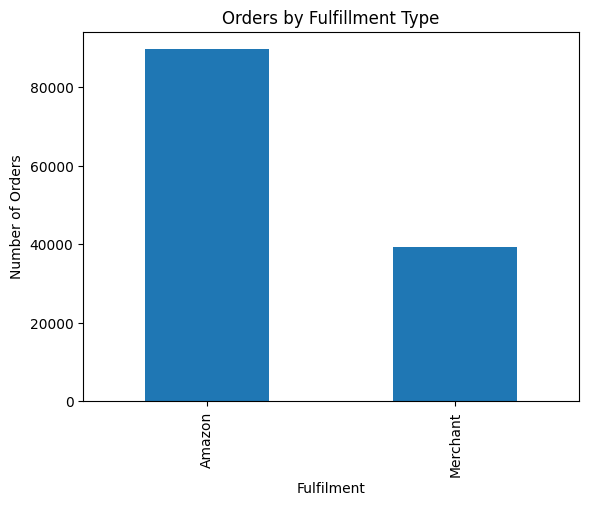

In [107]:
fulfillment_counts = df['Fulfilment'].value_counts()

fulfillment_counts.plot(kind='bar')

plt.title('Orders by Fulfillment Type')
plt.ylabel('Number of Orders')
plt.show()

In [108]:
df['Courier Status'].value_counts()

,count
Courier Status,
Shipped,109463
Unknown,6871
Unshipped,6681
Cancelled,5934


In [109]:
df.groupby('fulfilled-by')['Amount'].agg(['count','sum'])

,count,sum
fulfilled-by,,
Easy Ship,39270,25315999.94
Not Specified,89679,57974543.00


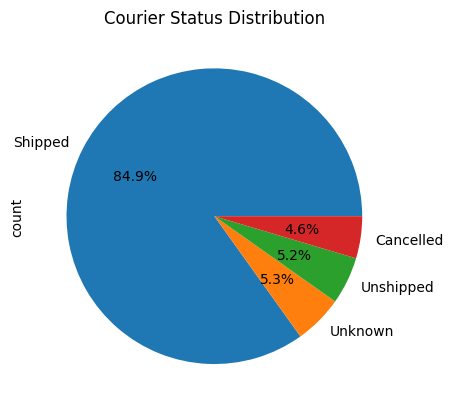

In [110]:
courier_status = df['Courier Status'].value_counts()

courier_status.plot(kind='pie', autopct='%1.1f%%')

plt.title('Courier Status Distribution')
plt.show()

**Assignment task 4 :** Product Management & Inventory Optimization

In [111]:
category_qty = df.groupby('Category')['Qty'].sum().sort_values(ascending=False)

category_qty

,Qty
Category,
Set,45288
kurta,45049
Western Dress,13943
Top,9902
Ethnic Dress,1052
Blouse,864
Bottom,398
Saree,152
Dupatta,3


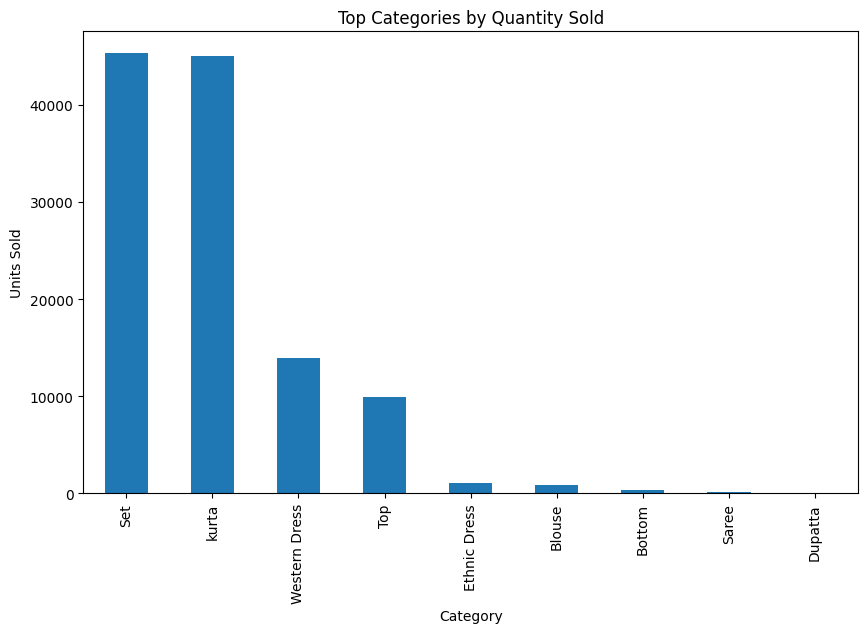

In [112]:
plt.figure(figsize=(10,6))

category_qty.head(10).plot(kind='bar')

plt.title('Top Categories by Quantity Sold')
plt.ylabel('Units Sold')

plt.show()

In [113]:
avg_qty = df.groupby('Category')['Qty'].mean().sort_values(ascending=False)

avg_qty

,Qty
Category,
Dupatta,1.000000
Blouse,0.933045
Top,0.932304
Saree,0.926829
Ethnic Dress,0.908463
Bottom,0.904545
kurta,0.903383
Set,0.900806
Western Dress,0.899839


In [114]:
top_sku = df.groupby('SKU')['Qty'].sum().sort_values(ascending=False)

top_sku.head(10)

,Qty
SKU,
JNE3797-KR-L,661
JNE3797-KR-M,561
JNE3797-KR-S,503
JNE3405-KR-L,485
J0230-SKD-M,469
J0230-SKD-S,421
JNE3797-KR-XL,416
JNE3405-KR-S,399
JNE3797-KR-XS,386


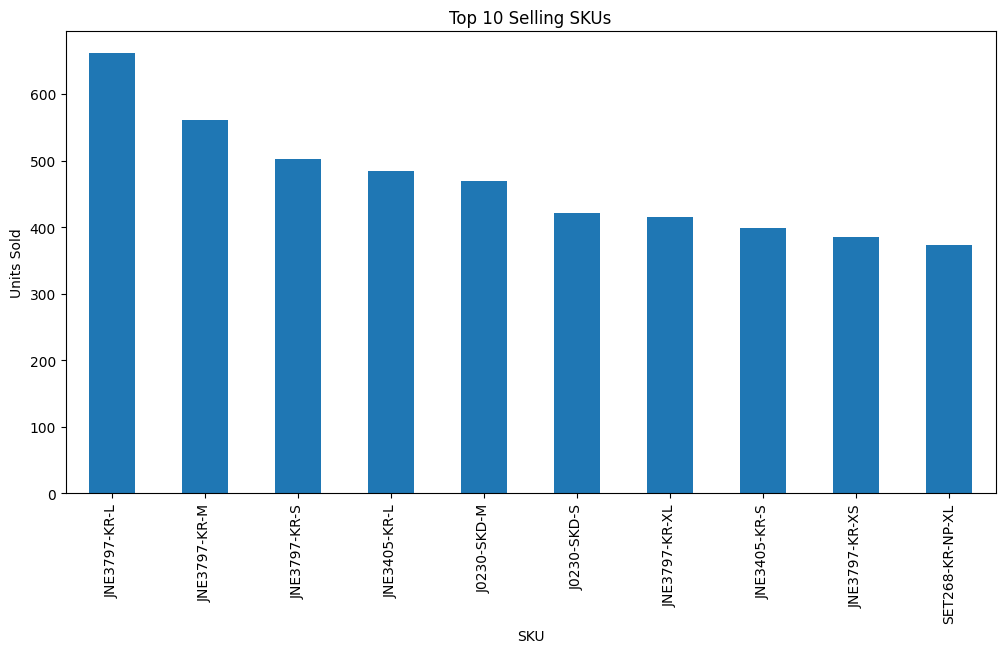

In [115]:
plt.figure(figsize=(12,6))

top_sku.head(10).plot(kind='bar')

plt.title('Top 10 Selling SKUs')
plt.ylabel('Units Sold')

plt.show()

In [116]:
top_style = df.groupby('Style')['Qty'].sum().sort_values(ascending=False)

top_style.head(10)

,Qty
Style,
JNE3797,3693
JNE3405,2066
SET268,1732
J0230,1711
J0341,1472
J0003,1390
SET324,1153
SET345,1134
JNE3373,1070


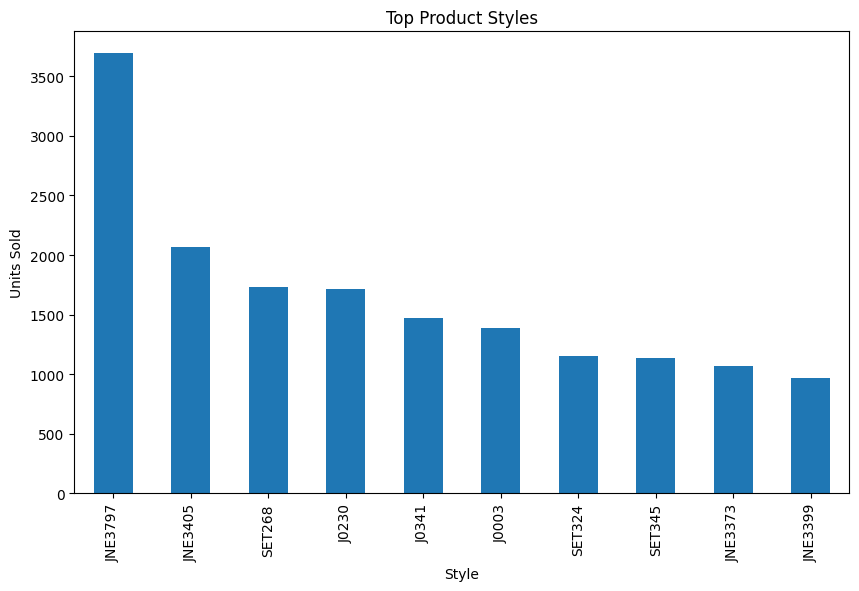

In [117]:
plt.figure(figsize=(10,6))

top_style.head(10).plot(kind='bar')

plt.title('Top Product Styles')
plt.ylabel('Units Sold')

plt.show()

**Assignment Task 5 :** Customer Satisfaction & Returns Analysis

In [118]:
returns = df[df['Status'].str.contains('Returned|Returning', case=False, na=False)]

returns['Status'].value_counts()

,count
Status,
Shipped - Returned to Seller,1953
Shipped - Returning to Seller,145


In [119]:
cancelled_revenue = df[df['Status']=='Cancelled']['Amount'].sum()

print(cancelled_revenue)

11501734.319999998


In [120]:
cancelled = df[df['Status']=='Cancelled']

cancelled_revenue = cancelled['Amount'].sum()

print(f"Revenue Lost Due to Cancellation: ₹{cancelled_revenue:,.2f}")

Revenue Lost Due to Cancellation: ₹11,501,734.32


In [121]:
returns_by_category = (
    returns.groupby('Category')['Qty']
    .sum()
    .sort_values(ascending=False)
)

returns_by_category

,Qty
Category,
Set,843
kurta,765
Western Dress,342
Top,135
Ethnic Dress,16
Blouse,12
Bottom,6
Saree,1


In [122]:
cancelled_category = (
    df[df['Status']=='Cancelled']
    .groupby('Category')['Qty']
    .sum()
    .sort_values(ascending=False)
)

cancelled_category

,Qty
Category,
kurta,2262
Set,2262
Top,536
Western Dress,529
Ethnic Dress,38
Blouse,32
Bottom,14
Saree,5


The analysis reveals that the company is performing strongly in key product categories such as Set and Kurta, which contribute the highest sales volume and revenue. Maharashtra, Karnataka, and Telangana emerge as the most valuable markets, while Bengaluru and Hyderabad are the leading revenue-generating cities.

Customer analysis indicates that the business is predominantly B2C-driven, though B2B customers exhibit a higher average order value. Logistics operations are largely dependent on Amazon fulfillment, which handles the majority of orders and revenue generation.

Despite strong sales performance, the company faces challenges related to order cancellations and product returns. Approximately 14.22% of orders are cancelled, resulting in an estimated revenue loss of ₹11.5 million. Returns are concentrated in the highest-selling categories, highlighting opportunities for improvements in product quality, sizing accuracy, and customer communication.

By strengthening inventory management, improving logistics visibility, reducing cancellations, and focusing on high-performing markets and products, the company can enhance customer satisfaction, improve operational efficiency, and achieve sustainable business growth.
